## 📥 Data Input

**Concepts:** [Graph model](../problem.md#the-graph-model) **Reference:** [Input Formats](../reference/input_formats.md) **Advanced API:** [📥 Data Input](lo11_data_input.ipynb)

A problem instance for _OptiWindNet_ is made of a **location**— turbine and substation positions, plus the optional border and obstacles — and the properties of the available **cable types**. Both are described in [Input Formats](../reference/input_formats.md), which also specifies each of the file formats read below.

This notebook shows how to pass each of them to a [WindFarmNetwork](../autoapi/optiwindnet/api/index.rst#optiwindnet.api.WindFarmNetwork) instance.

A _location_ describes the geometrical part of the data: positions and boundaries. This notebook focuses on the alternatives to provide location data, which present a much greater volume and complexity than the cable properties.

The problem instances are contained in instances of the [WindFarmNetwork](../autoapi/optiwindnet/api/index.rst#optiwindnet.api.WindFarmNetwork) class. The geometric data can be initialized with:

- coordinates (contained in Numpy arrays)
- a location object `L` (a NetworkX Graph instance)
- an [windIO](https://github.com/IEAWindSystems/windIO) `.yaml` file
- a `.yaml` file (OptiWindNet's schema)
- a `.osm.pbf` file

Additionally, the cable properties must also be provided at intialization.

In [1]:
cables = 4

In [2]:
from optiwindnet.api import WindFarmNetwork

### Provide coordinates

In [3]:
import numpy as np

In [4]:
# all coordinates are sequences of (x, y) pairs
# if input coordinates are in arrays X and Y, use `np.hstack((X, Y))`
borderC = np.array( # coordinate sequence defines the polygon, last-first segment implicit
    [[1951, 200], [1951, 1383], [386, 1383], [650, 708], [624, 678],
     [4, 1036], [4, 3], [1152, 3], [917, 819], [957, 854]],
    dtype=float)
obstacleC_ = [
    # first obstacle
    np.array([[1540, 920], [1600, 940], [1600, 1150], [1400, 1200]]),
    # [second obstacle] ...
]
substationsC = np.array([[696, 1063],], dtype=float)
turbinesC = np.array(
    [[1940, 279], [1920, 703], [1475, 696], [1839, 1250],
     [1277, 1296], [442, 1359], [737, 435], [1060, 26],
     [522, 176], [87, 35], [184, 417], [71, 878]],
    dtype=float)

In [5]:
wfn_coords = WindFarmNetwork(
    turbinesC=turbinesC,
    substationsC=substationsC,
    cables=cables,
    borderC=borderC,
    obstacleC_=obstacleC_,
)

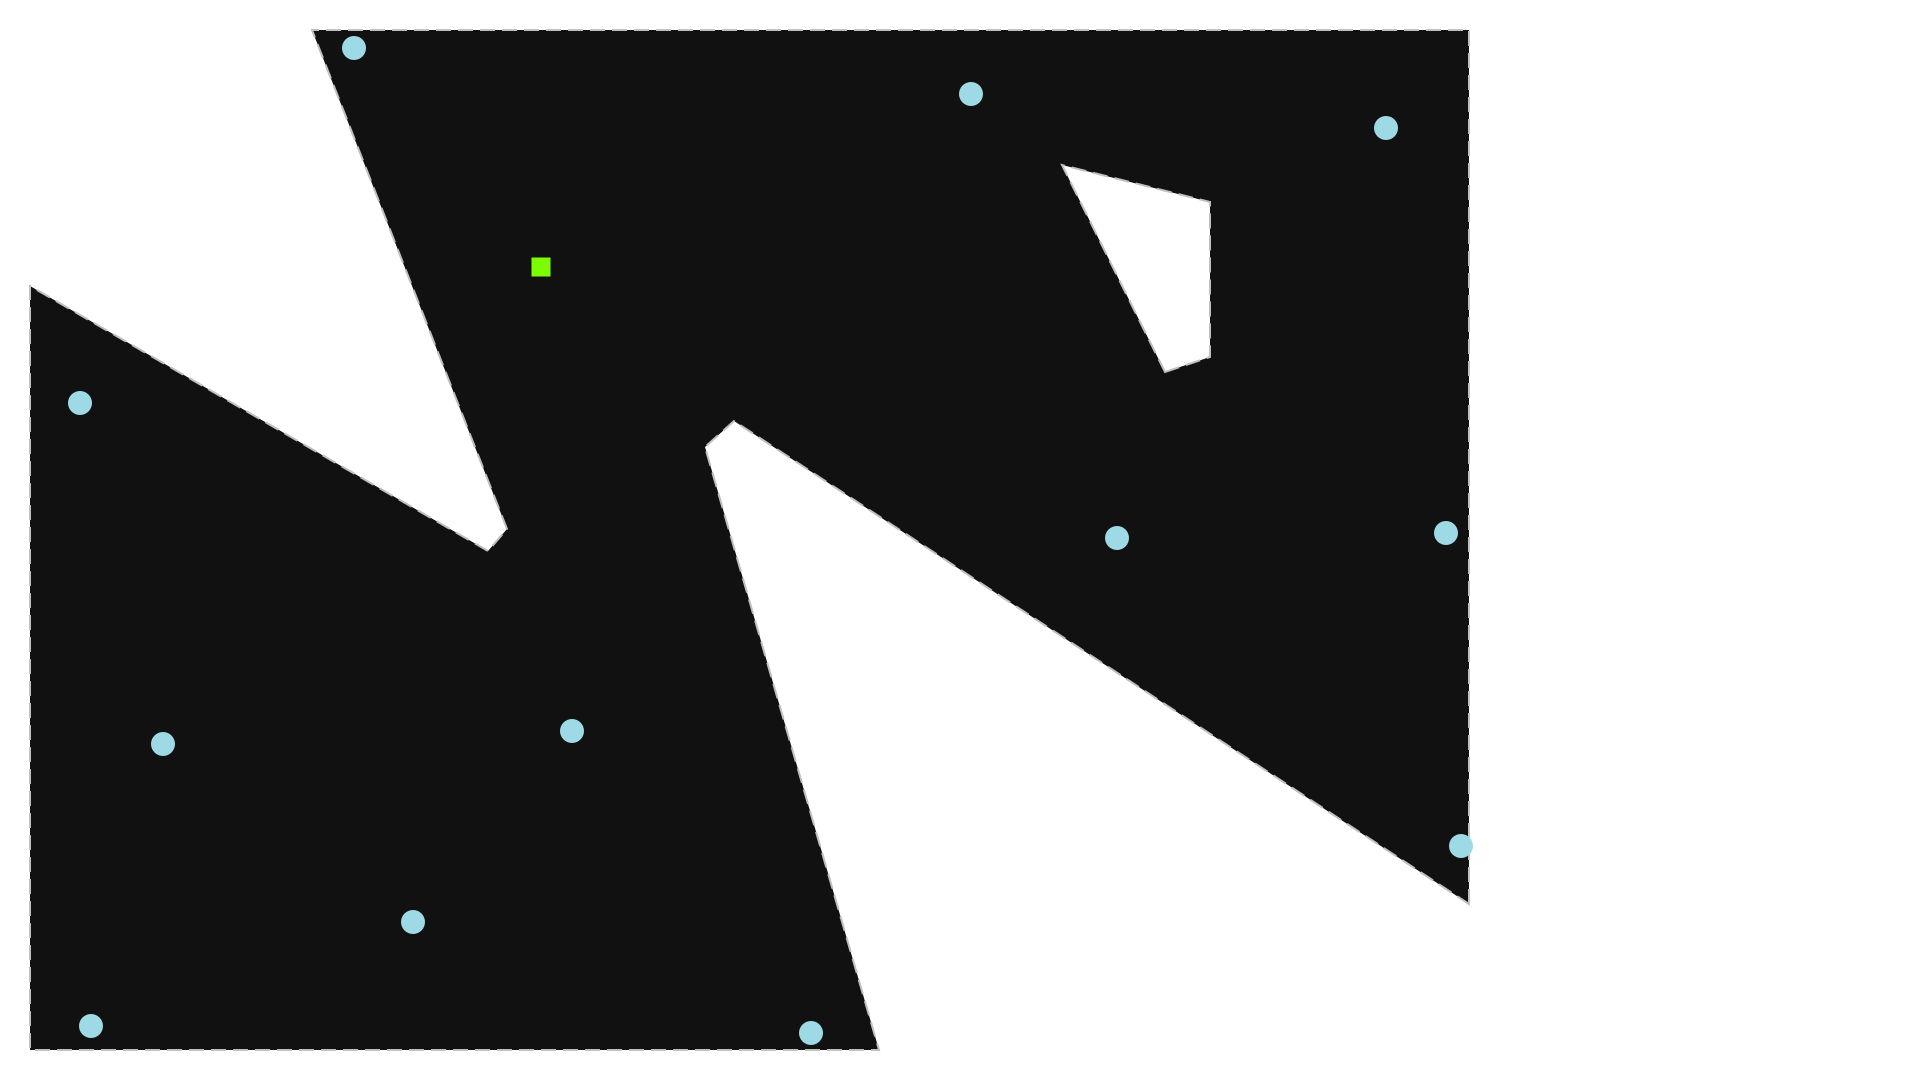

In [6]:
wfn_coords

### Provide a location instance `L`

In [7]:
from optiwindnet.api import load_repository

In [8]:
locations = load_repository()

> Note: [load_repository()](../autoapi/optiwindnet/importer/index.rst#optiwindnet.importer.load_repository) loads locations from all `.yaml` (OptiWindNet) and `.osm.pbf` files in the given directory. If no path is given, it loads the locations distributed with _OptiWindNet_. For more details, see [🗂️ Locations](hi12_locations.ipynb).

Initialize [WindFarmNetwork()](../autoapi/optiwindnet/api/index.rst#optiwindnet.api.WindFarmNetwork) instance with the loaded `L`:

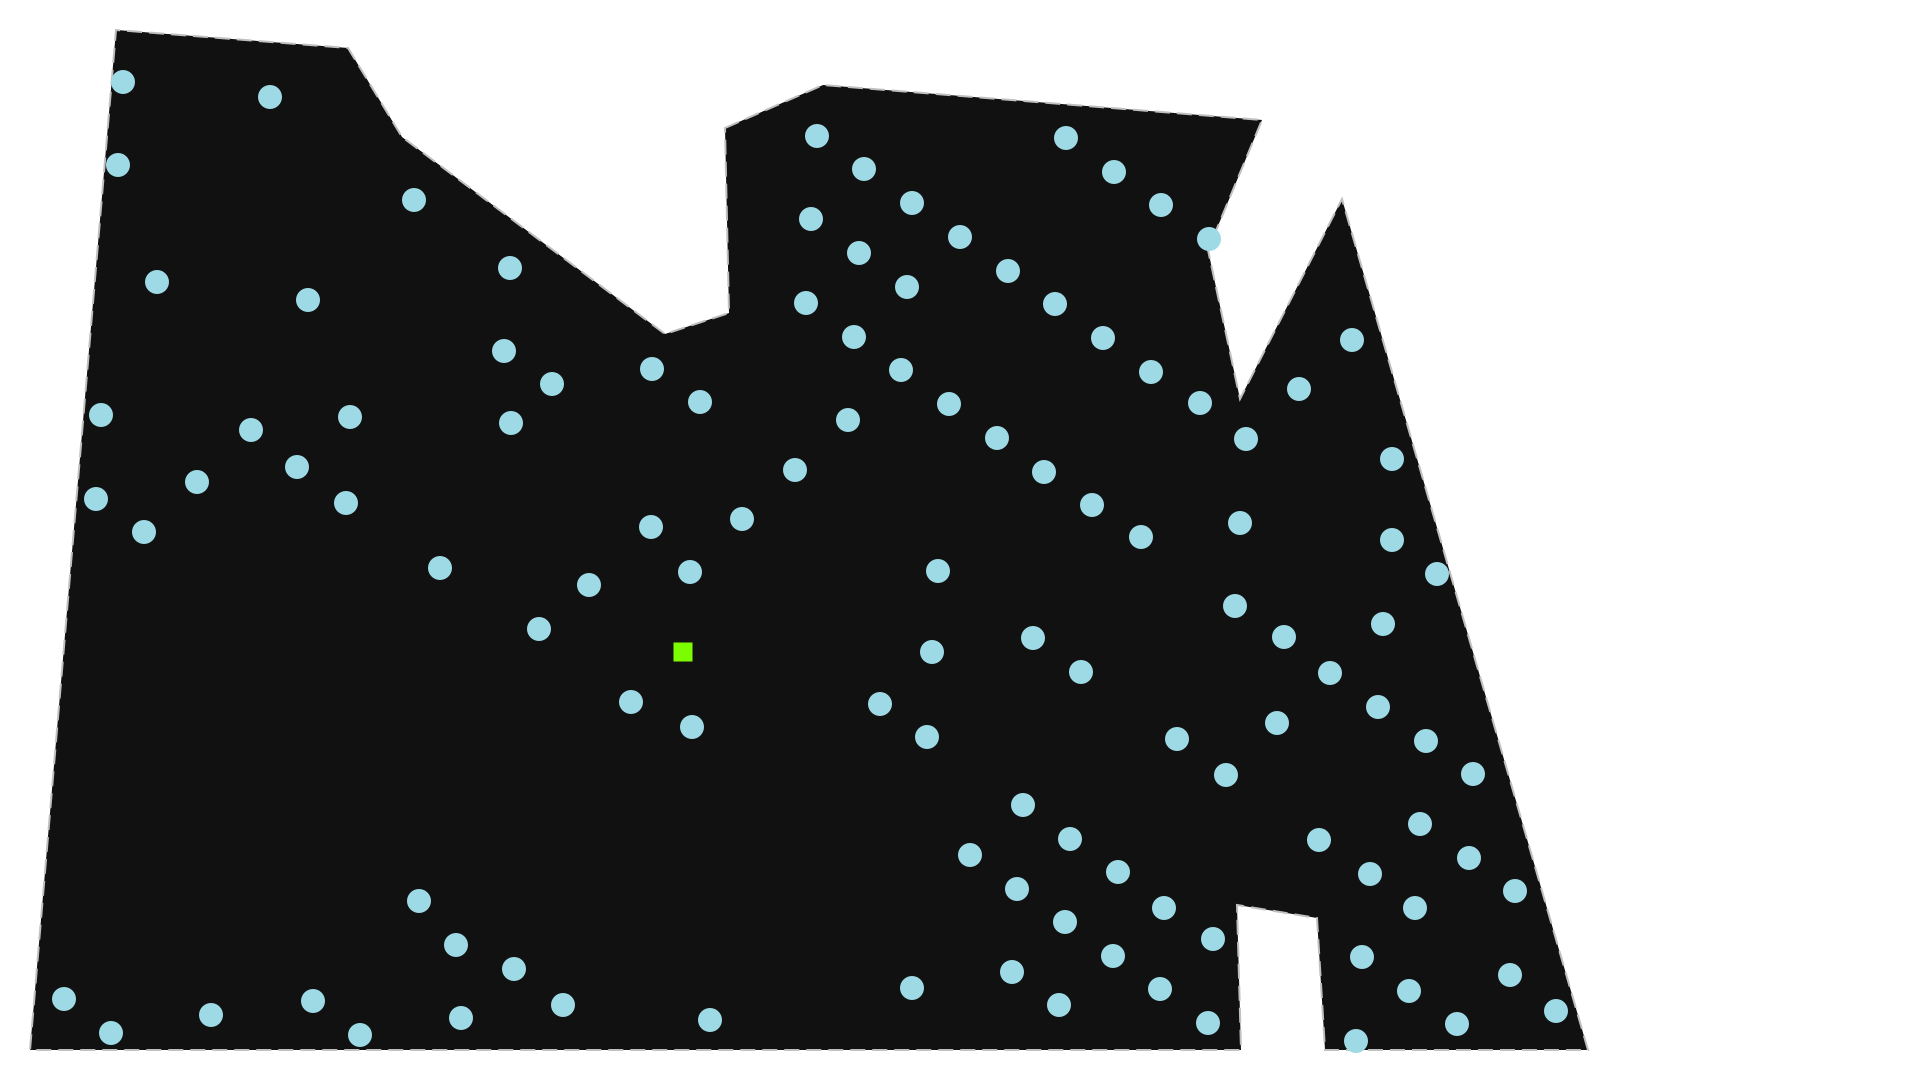

In [9]:
wfn_L = WindFarmNetwork(
    L=locations.seagreen,
    cables=cables,
)
wfn_L

### Provide an windIO YAML file

[windIO](https://github.com/IEAWindSystems/windIO) is a community data format for wind energy system models — see [windIO YAML](../reference/input_formats.md#windio-yaml).

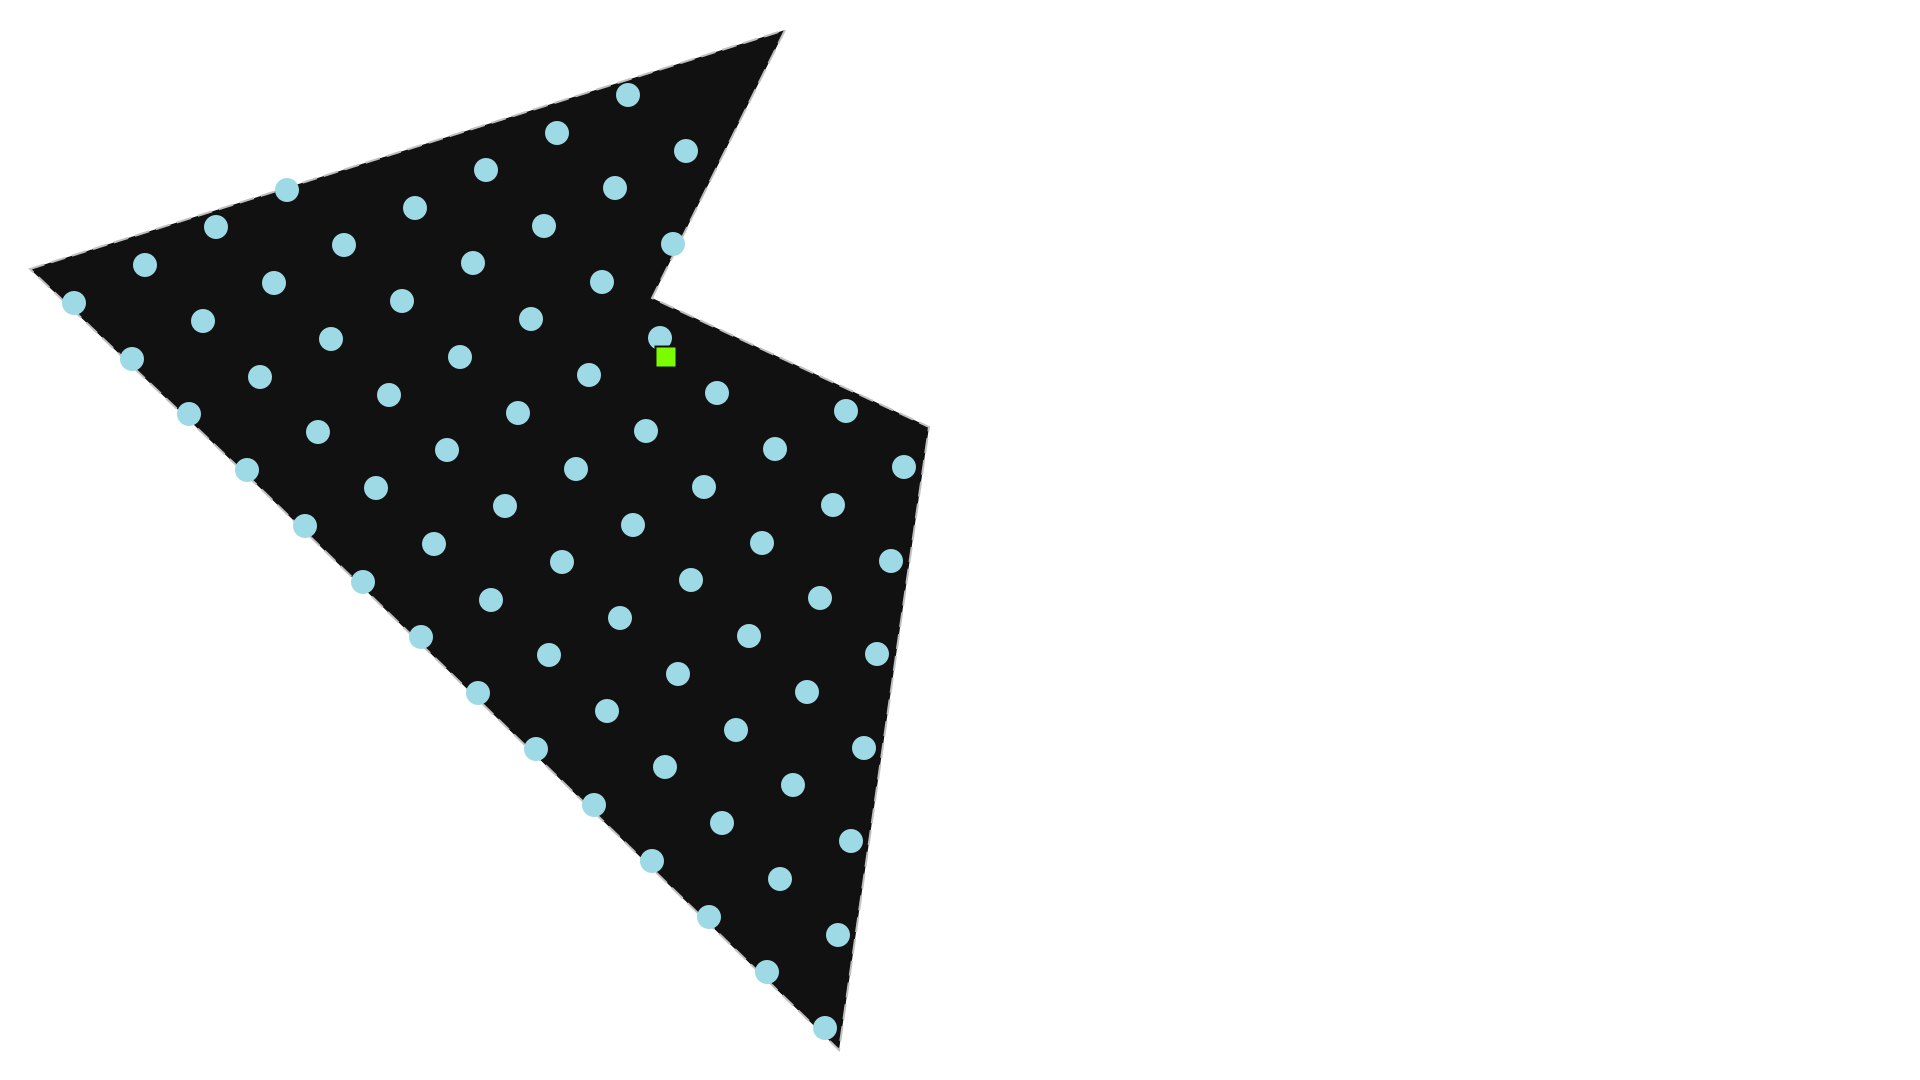

In [10]:
wfn_windIO = WindFarmNetwork.from_windIO(
    filepath='data/IEA37_Borssele_Regular_System.yaml',
    cables=cables,
)
wfn_windIO

### Provide an OptiWindNet YAML file

This option loads the location geometry from a `.yaml` file, which is useful for working with saved or external project files in this format. A sample code snippet for generating `.yaml` files with the proper structure is provided below.

Several `.yaml` examples can be found in the folder `optiwindnet/data`. Look for them in Python's `site-packages` or in [OptiWindNet's repository](https://gitlab.windenergy.dtu.dk/TOPFARM/OptiWindNet/-/tree/main/optiwindnet/data).

In [11]:
with open('data/example_location.yaml', 'w') as yaml_file:
    yaml_file.write('''
# coordinate format can be "planar" or "latlon"
#   - for "latlon" examples, see `optiwindnet/data/*.yaml`
#   - this field is optional, default is "latlon"
#   - coordinates are converted to floats, so floats may be used as well
COORDINATE_FORMAT: planar

# extents define a polygon:
#   - do not repeat the initial vertex at the end
#   - line breaks are optional
EXTENTS: [
  [1951, 200],
  [1951, 1383],
  [386, 1383],
  [650, 708],
  [624, 678],
  [4, 1036],
  [4, 3],
  [1152, 3],
  [917, 819],
  [957, 854]
]

# obstacles is optional and must be a list of polygons (even if 1 obstacle)
OBSTACLES: [
  [  # first obstacle
    [1540, 920],
    [1600, 940],
    [1600, 1150],
    [1400, 1200],
  ],
  # [second obstacle]
]

SUBSTATIONS: [
  [696, 1063],
]

TURBINES: [
  [1940, 279],
  [1920, 703],
  [1475, 696],
  [1839, 1250],
  [1277, 1296],
  [442, 1359],
  [737, 435],
  [1060, 26],
  [522, 176],
  [87, 35],
  [184, 417],
  [71, 878],
]
''')

Initialize [WindFarmNetwork()](../autoapi/optiwindnet/api/index.rst#optiwindnet.api.WindFarmNetwork) instance with an existing `.yaml` file:

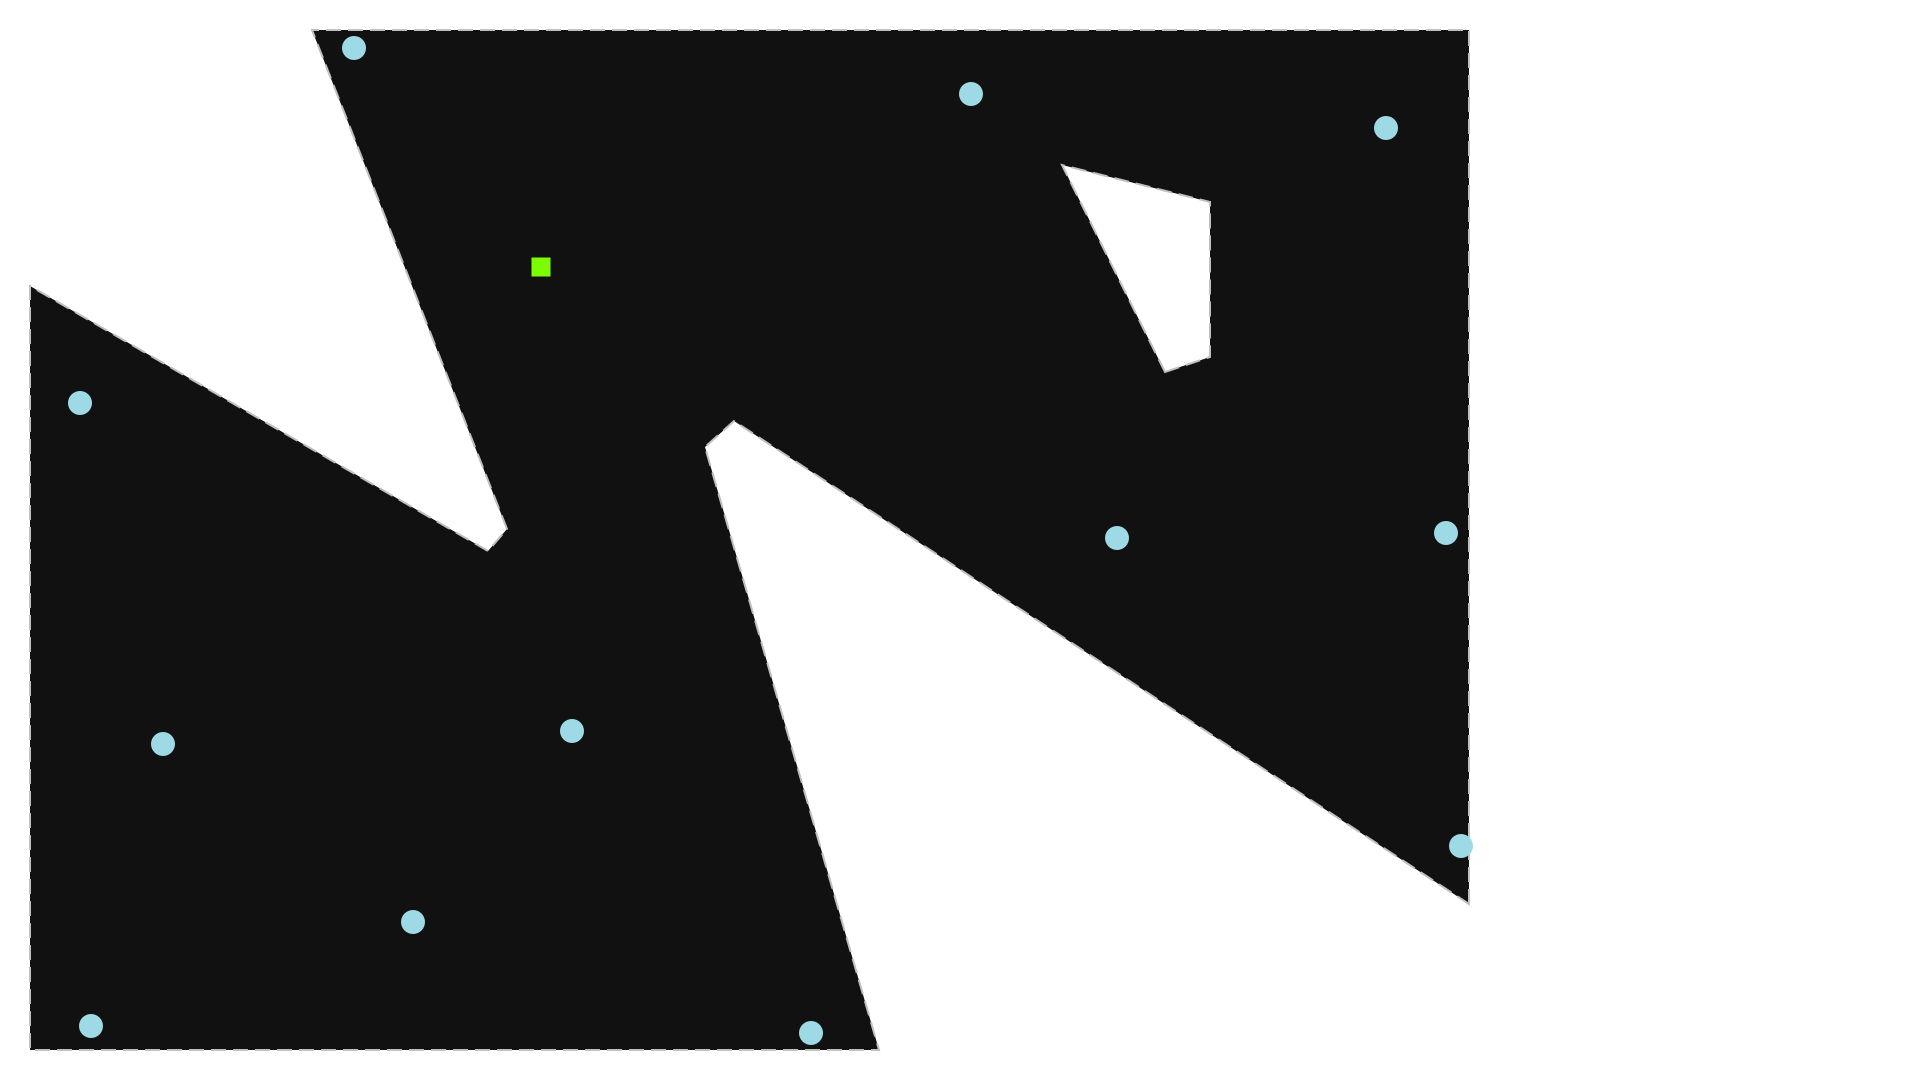

In [12]:
wfn_yaml = WindFarmNetwork.from_own_yaml(
    filepath='data/example_location.yaml',
    cables=cables,
)
wfn_yaml

### Provide an OSM.PBF file

> `osm.pbf` stands for _OpenStreetMap Protocolbuffer Binary Format (PBF)_.

This option loads the location geometry from a `.osm.pbf` file, which is useful for working with saved or external project files in this format.

Several `.osm.pbf` examples can be found in the folder `optiwindnet/data`. Look for them in Python's `site-packages` or in [OptiWindNet's repository](https://gitlab.windenergy.dtu.dk/TOPFARM/OptiWindNet/-/tree/main/optiwindnet/data).

> The OpenStreetMap tagging conventions _OptiWindNet_ expects — which tags mark turbines, substations, the border and the obstacles — are described in [OpenStreetMap PBF](../reference/input_formats.md#openstreetmap-pbf).

Initialize [WindFarmNetwork()](../autoapi/optiwindnet/api/index.rst#optiwindnet.api.WindFarmNetwork) instance with an existing `.osm.pbf` file:

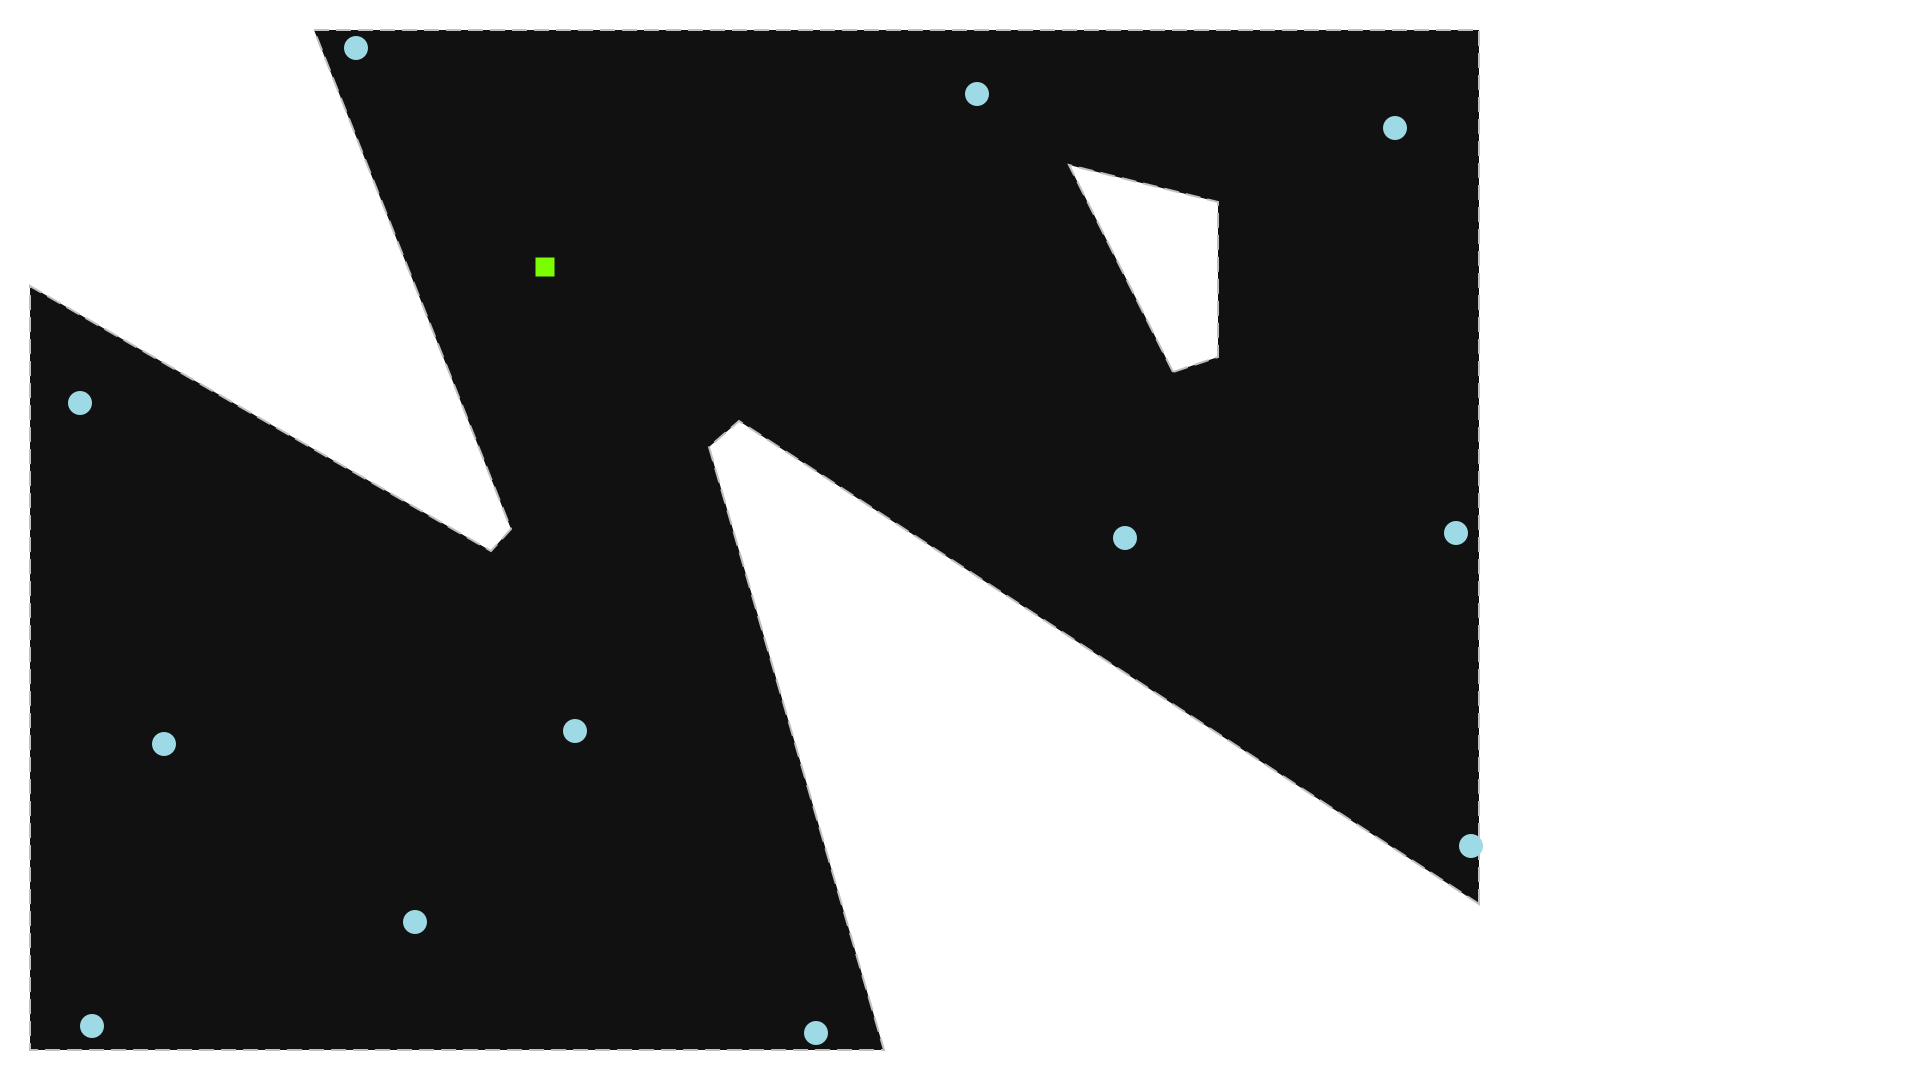

In [13]:
wfn_pbf = WindFarmNetwork.from_pbf(
    filepath='data/example_location.osm.pbf',
    cables=cables,
)
wfn_pbf